In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

In [2]:
basic1 = pd.read_csv("./colors/basic1.csv")
basic1.head()

,x,y,color
0,79.408289,152.834424,0
1,98.046263,186.910700,0
2,240.578979,48.473684,1
3,109.687183,277.945769,0
4,249.626082,229.753352,1


In [3]:
basic1['color'].unique()

array([0, 1, 3, 2], dtype=int64)

In [4]:
df1 = basic1[basic1["color"] == 0]
df2 = basic1[basic1["color"] == 1]
df3 = basic1[basic1["color"] == 2]
df4 = basic1[basic1["color"] == 3]

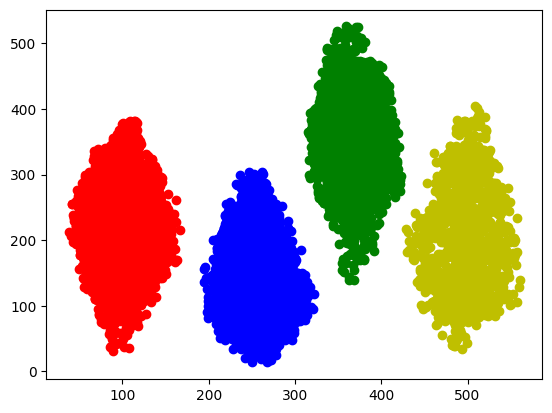

In [5]:
plt.scatter(df1["x"],df1["y"],c="r")
plt.scatter(df2["x"],df2["y"],c="b")
plt.scatter(df3["x"],df3["y"],c="g")
plt.scatter(df4["x"],df4["y"],c="y")

##### Elbow to check how much machine could organize well

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\si

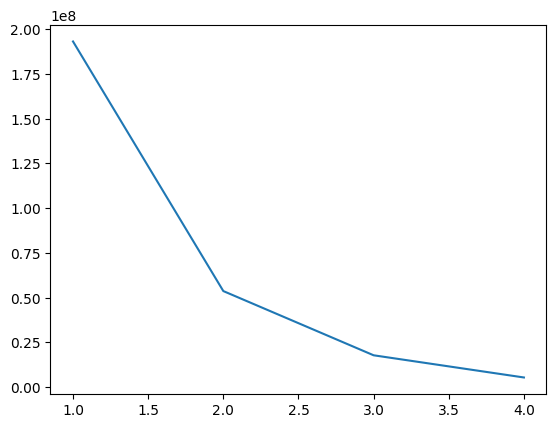

In [6]:
sse = []
for k in range(1,5):
    KM = KMeans(k)
    KM.fit(basic1[["x"]],basic1[["y"]])
    sse.append(KM.inertia_)

plt.plot(range(1,5),sse)


### KMeans

In [7]:
KM = KMeans(n_clusters=4)

In [23]:
KM.fit(basic1[["x"]])

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=4)

In [24]:
clusters = KM.predict(basic1[["x"]])
np.unique(clusters)

array([0, 1, 2, 3])

In [27]:
basic1["KMeans_clusters"] = clusters

In [28]:
basic1.tail()

,x,y,color,KMeans_clusters
9789,271.341817,152.122986,1,3
9790,374.928092,424.480854,2,1
9791,496.467434,317.553201,3,2
9792,484.710737,251.504081,3,2
9793,358.131243,445.470938,2,1


In [29]:
df1 = basic1[basic1["KMeans_clusters"] == 0]
df2 = basic1[basic1["KMeans_clusters"] == 1]
df3 = basic1[basic1["KMeans_clusters"] == 2]
df4 = basic1[basic1["KMeans_clusters"] == 3]

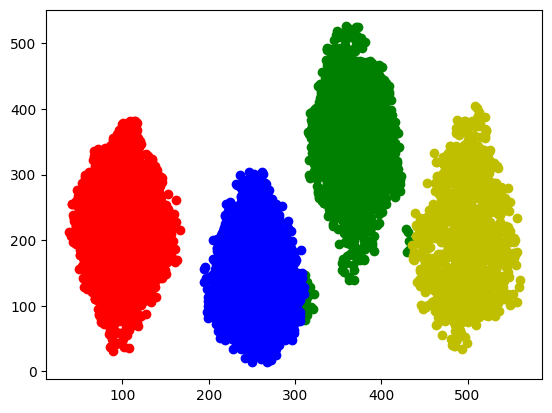

In [30]:
plt.scatter(df1["x"],df1["y"],c="r")
plt.scatter(df2["x"],df2["y"],c="g")
plt.scatter(df3["x"],df3["y"],c="y")
plt.scatter(df4["x"],df4["y"],c="b")

### DBSCAN

In [165]:
DB = DBSCAN(eps=6,min_samples=50)

In [166]:
clusters = DB.fit_predict(basic1[["x"]])

In [167]:
np.unique(clusters)

array([-1,  0,  1,  2,  3], dtype=int64)

In [168]:
basic1["DBSCAN_clusters"] = clusters

In [169]:
df1 = basic1[basic1["DBSCAN_clusters"] == -1]
df2 = basic1[basic1["DBSCAN_clusters"] == 0]
df3 = basic1[basic1["DBSCAN_clusters"] == 1]
df4 = basic1[basic1["DBSCAN_clusters"] == 2]
df5 = basic1[basic1["DBSCAN_clusters"] == 3]

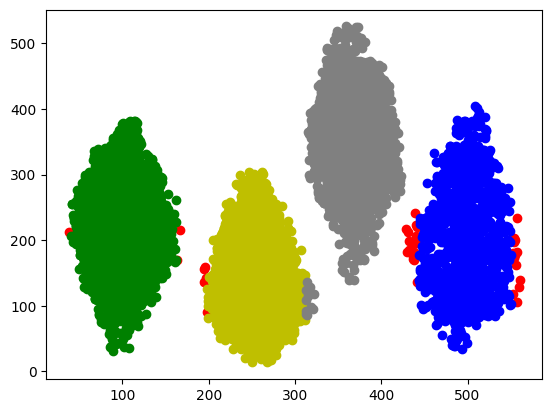

In [170]:
plt.scatter(df1["x"],df1["y"],c="r")
plt.scatter(df2["x"],df2["y"],c="g")
plt.scatter(df3["x"],df3["y"],c="y")
plt.scatter(df4["x"],df4["y"],c="b")
plt.scatter(df5["x"],df5["y"],c="gray")